# Te damos la bienvenida a Colab

#**1. Introducción**

El mercado inmobiliario de alojamientos de corta duración ha transformado la dinámica urbana en las últimas décadas, siendo plataformas como Airbnb los principales catalizadores de este cambio.  
En particular, la plataforma antes mencionada domina el mercado de alquiler vacacional en Europa, siendo usado por millones de turistas al año, lo que hace que sea un buen escenario para el análisis de datos.  

Este proyecto se enfoca en...




#**2. Exploración de datos**

Dedicaremos esta sección del informe a la exploración de datos, donde se mostrarán características importantes estadísticas, gráficos, y limpieza de los datos a utilizar.

##**Lectura del dataset**

In [ ]:
!pip -q install pyarrow

In [ ]:
import pandas as pd
import gdown
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/Rajevic-0/Proyecto-Mineria-De-Datos/21614a18231f34a2f38d2e238fca764d134ef4a2/listings.parquet"
try:
  df_init = pd.read_parquet(url, engine="pyarrow")
  print("Carga Exitosa")
  print(f"Dimensiones: {df_init.shape}")

except Exception as e:
  print(f"\nError crítico al procesar el archivo: {e}")

df_init.head(10)

Carga Exitosa
Dimensiones: (95898, 61)


,listing_id,listing_type,room_type,cover_photo_url,photos_count,host_id,superhost,latitude,longitude,guests,...,l90d_revpar_native,l90d_adjusted_revpar,l90d_adjusted_revpar_native,l90d_reserved_days,l90d_blocked_days,l90d_available_days,l90d_total_days,country,state,city
0,121902,Entire home,entire_home,https://a0.muscache.com/im/pictures/77c0e3a9-0...,77,fe453949b595,false,37.0758,27.2426,6,...,0.0,0.0,0.0,0,90,90,90,Turkey,Muğla,Bodrum
1,805342,Entire condo,entire_home,https://a0.muscache.com/im/pictures/11494599/4...,16,59711ec4c245,false,37.0092,27.2563,3,...,0.0,0.0,0.0,0,0,90,90,Turkey,Muğla,Bodrum
2,805361,Entire home,entire_home,https://a0.muscache.com/im/pictures/bda48dbc-d...,34,d217bf6e3427,false,37.0292,27.4410,5,...,0.0,0.0,0.0,0,0,90,90,Turkey,Muğla,Bodrum
3,853827,Entire villa,entire_home,https://a0.muscache.com/im/pictures/26626113/a...,70,605fc7d80e02,false,37.0434,27.2517,16,...,536.3,0.0,0.0,2,0,88,90,Turkey,Muğla,Bodrum
4,967193,Entire villa,entire_home,https://a0.muscache.com/im/pictures/68107669/2...,37,3b963e8cd040,false,37.0429,27.3898,4,...,0.0,0.0,0.0,0,0,90,90,Turkey,Muğla,Bodrum
5,997955,Entire rental unit,entire_home,https://a0.muscache.com/im/pictures/b953e3a8-2...,42,f4545706f365,true,37.0348,27.4227,6,...,817.9,0.0,0.0,19,0,71,90,Turkey,Muğla,Bodrum
6,1149100,Entire home,entire_home,https://a0.muscache.com/im/pictures/hosting/Ho...,55,e4a9bcf47b5d,true,37.0663,27.2455,6,...,0.0,0.0,0.0,0,0,90,90,Turkey,Muğla,Bodrum
7,1618625,Entire rental unit,entire_home,https://a0.muscache.com/im/pictures/miso/Hosti...,26,6176a31312ef,true,36.9705,27.2830,6,...,134.3,0.0,0.0,3,0,87,90,Turkey,Muğla,Bodrum
8,1651024,Entire home,entire_home,https://a0.muscache.com/im/pictures/46597033/8...,35,bf7f99951cbf,false,37.1428,27.3277,5,...,0.0,0.0,0.0,0,0,90,90,Turkey,Muğla,Bodrum
9,2052424,Entire home,entire_home,https://a0.muscache.com/im/pictures/hosting/Ho...,75,824b74573fa1,false,37.0405,27.2631,7,...,0.0,0.0,0.0,0,0,90,90,Turkey,Muğla,Bodrum


##**Exploración de Datos**

Comenzamos con simples .describe() y .info() para obtener información importante de los atributos, especialmente con el segundo método.

In [ ]:
df_init.describe()

,listing_id,listing_type,room_type,cover_photo_url,photos_count,host_id,superhost,latitude,longitude,guests,...,l90d_revpar_native,l90d_adjusted_revpar,l90d_adjusted_revpar_native,l90d_reserved_days,l90d_blocked_days,l90d_available_days,l90d_total_days,country,state,city
count,95898,95329,95329,95102,95102,95329,95322,95327,95273,84865,...,95329,95329,95329,95329,95329,95329,94854,95898,95898,95898
unique,95882,129,485,94429,689,68528,473,55034,63476,24,...,6114,2670,4254,94,93,92,5,36,136,373
top,"⭐⭐⭐⭐⭐""",Entire rental unit,entire_home,18,16,ad1c8827240f,false,40.6318,4,4,...,0.0,0.0,0.0,0,0,90,90,France,England,Olbia
freq,6,47104,81709,19,3103,81,52890,28,142,26729,...,37224,71407,71044,37136,56248,37331,94850,25253,8650,308


In [ ]:
df_init.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95898 entries, 0 to 95897
Data columns (total 61 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   listing_id                   95898 non-null  object
 1   listing_type                 95329 non-null  object
 2   room_type                    95329 non-null  object
 3   cover_photo_url              95102 non-null  object
 4   photos_count                 95102 non-null  object
 5   host_id                      95329 non-null  object
 6   superhost                    95322 non-null  object
 7   latitude                     95327 non-null  object
 8   longitude                    95273 non-null  object
 9   guests                       84865 non-null  object
 10  bedrooms                     78576 non-null  object
 11  beds                         94336 non-null  object
 12  baths                        94994 non-null  object
 13  registration                 95

Vemos que la mayoría de los atributos del dataset tienen algún valor no nulo en valores cercanos al número total de registros. La única excepción es 'instant_book', el cual para este estudio no es relevante, por lo que lo quitamos del dataframe.

In [ ]:
df_init_dp = df_init.drop(columns='instant_book')

Seguimos con un bloque de código, cuya finalidad es darnos una tabla con la información de valores nulos presentes por atributo, y su porcentaje con respecto a los registros totales, para darnos una idea de cuantos valores nulos estamos hablando.

In [ ]:
import matplotlib.ticker as mticker

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"]=120

print("AUDITORÍA INSANA")
print("="*40)

print(f"\nRegistros : {df_init_dp.shape[0]: ,}")
print(f"Columnas : {df_init_dp.shape[1]}")

print("\n--- Tipos de columnas ---")
print(df_init_dp.dtypes.value_counts())

nulls = df_init_dp.isnull().sum()
nulls_pct = (nulls /len(df_init_dp)*100).round(2)
null_report = pd.DataFrame({
    "Nulos": nulls,
    "% del total": nulls_pct
}).query("Nulos >0").sort_values("% del total", ascending = False)

print(f"\n--- Columnas con valores nulos ({len(null_report)} columnas) ---")
print(null_report.to_string())

dupes= df_init_dp.duplicated().sum()
print(f"\nFIlas duplicadas: {dupes:,}")


AUDITORÍA INSANA

Registros :  95,898
Columnas : 60

--- Tipos de columnas ---
object    60
Name: count, dtype: int64

--- Columnas con valores nulos (56 columnas) ---
                             Nulos  % del total
bedrooms                     17322        18.06
guests                       11033        11.50
professional_management      10824        11.29
extra_guest_fee               3843         4.01
rating_accuracy               3183         3.32
rating_checkin                3183         3.32
rating_overall                3183         3.32
rating_cleanliness            3183         3.32
rating_communication          3183         3.32
rating_location               3183         3.32
rating_value                  3171         3.31
cleaning_fee                  2573         2.68
min_nights                    1691         1.76
beds                          1562         1.63
l90d_total_days               1044         1.09
amenities                      938         0.98
baths           

Podemos apreciar que los atributos con más valores nulos del dataset son los siguientes: 'bedrooms', guests' y 'professional_management'. Hay que definir una manera de manejar estos valores.


Lo primero que se hace es quitar esos tres atributos, ya que son irrelevantes para las preguntas y el contexto del proyecto. Sin mencionar que, considerando los gráficos que se obtuvieron con respecto a las características de los datos, no influyen mucho en temas de correlaciones o covarianzas (al menos, no para este proyecto).

In [ ]:
df_init_dp = df_init_dp.drop(columns=['bedrooms', 'guests', 'professional_management'])

Aún con esto, siguen habiendo algunos datos nulos, así que se aplica otro método para lidiar con estos casos.

Como se pudo apreciar anteriormente, El resto de atributos no tienen muchas filas con valor nulo (comparado al tamaño del dataset general), por lo que reemplazamos esos valores con su moda.

In [ ]:
columns = ['listing_type', 'room_type', 'cover_photo_url', 'photos_count', 'host_id',
           'superhost', 'latitude', 'longitude', 'beds',
           'baths', 'registration', 'amenities', 'min_nights', 'cancellation_policy',
           'currency', 'cleaning_fee', 'extra_guest_fee', 'num_reviews', 'rating_overall',
           'rating_accuracy', 'rating_checkin', 'rating_cleanliness', 'rating_communication',
           'rating_location', 'rating_value', 'ttm_revenue', 'ttm_revenue_native',
           'ttm_avg_rate', 'ttm_avg_rate_native', 'ttm_occupancy', 'ttm_adjusted_occupancy',
           'ttm_revpar', 'ttm_revpar_native', 'ttm_adjusted_revpar', 'ttm_adjusted_revpar_native',
           'ttm_reserved_days', 'ttm_blocked_days', 'ttm_available_days', 'ttm_total_days',
           'l90d_revenue', 'l90d_revenue_native', 'l90d_avg_rate', 'l90d_avg_rate_native',
           'l90d_occupancy', 'l90d_adjusted_occupancy', 'l90d_revpar', 'l90d_revpar_native',
           'l90d_adjusted_revpar', 'l90d_adjusted_revpar_native', 'l90d_reserved_days',
           'l90d_blocked_days', 'l90d_available_days','l90d_total_days'
           ]

for col in columns:
  df_init_dp[col] = df_init_dp[col].fillna(df_init_dp[col].mode()[0])

Ahora eliminamos duplicados

In [ ]:
df = df_init_dp.drop_duplicates()
df.shape

(95896, 57)

listing_id             object
listing_type           object
room_type              object
cover_photo_url        object
photos_count           object
host_id                object
superhost              object
latitude               object
longitude              object
beds                   object
baths                  object
registration           object
amenities              object
min_nights             object
cancellation_policy    object
currency               object
cleaning_fee           object
extra_guest_fee        object
num_reviews            object
rating_overall         object
dtype: object


/tmp/ipykernel_1646/2524684958.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[c] = pd.to_numeric(df[c], errors="coerce")


num shape: (95896, 45) corr shape: (45, 45)


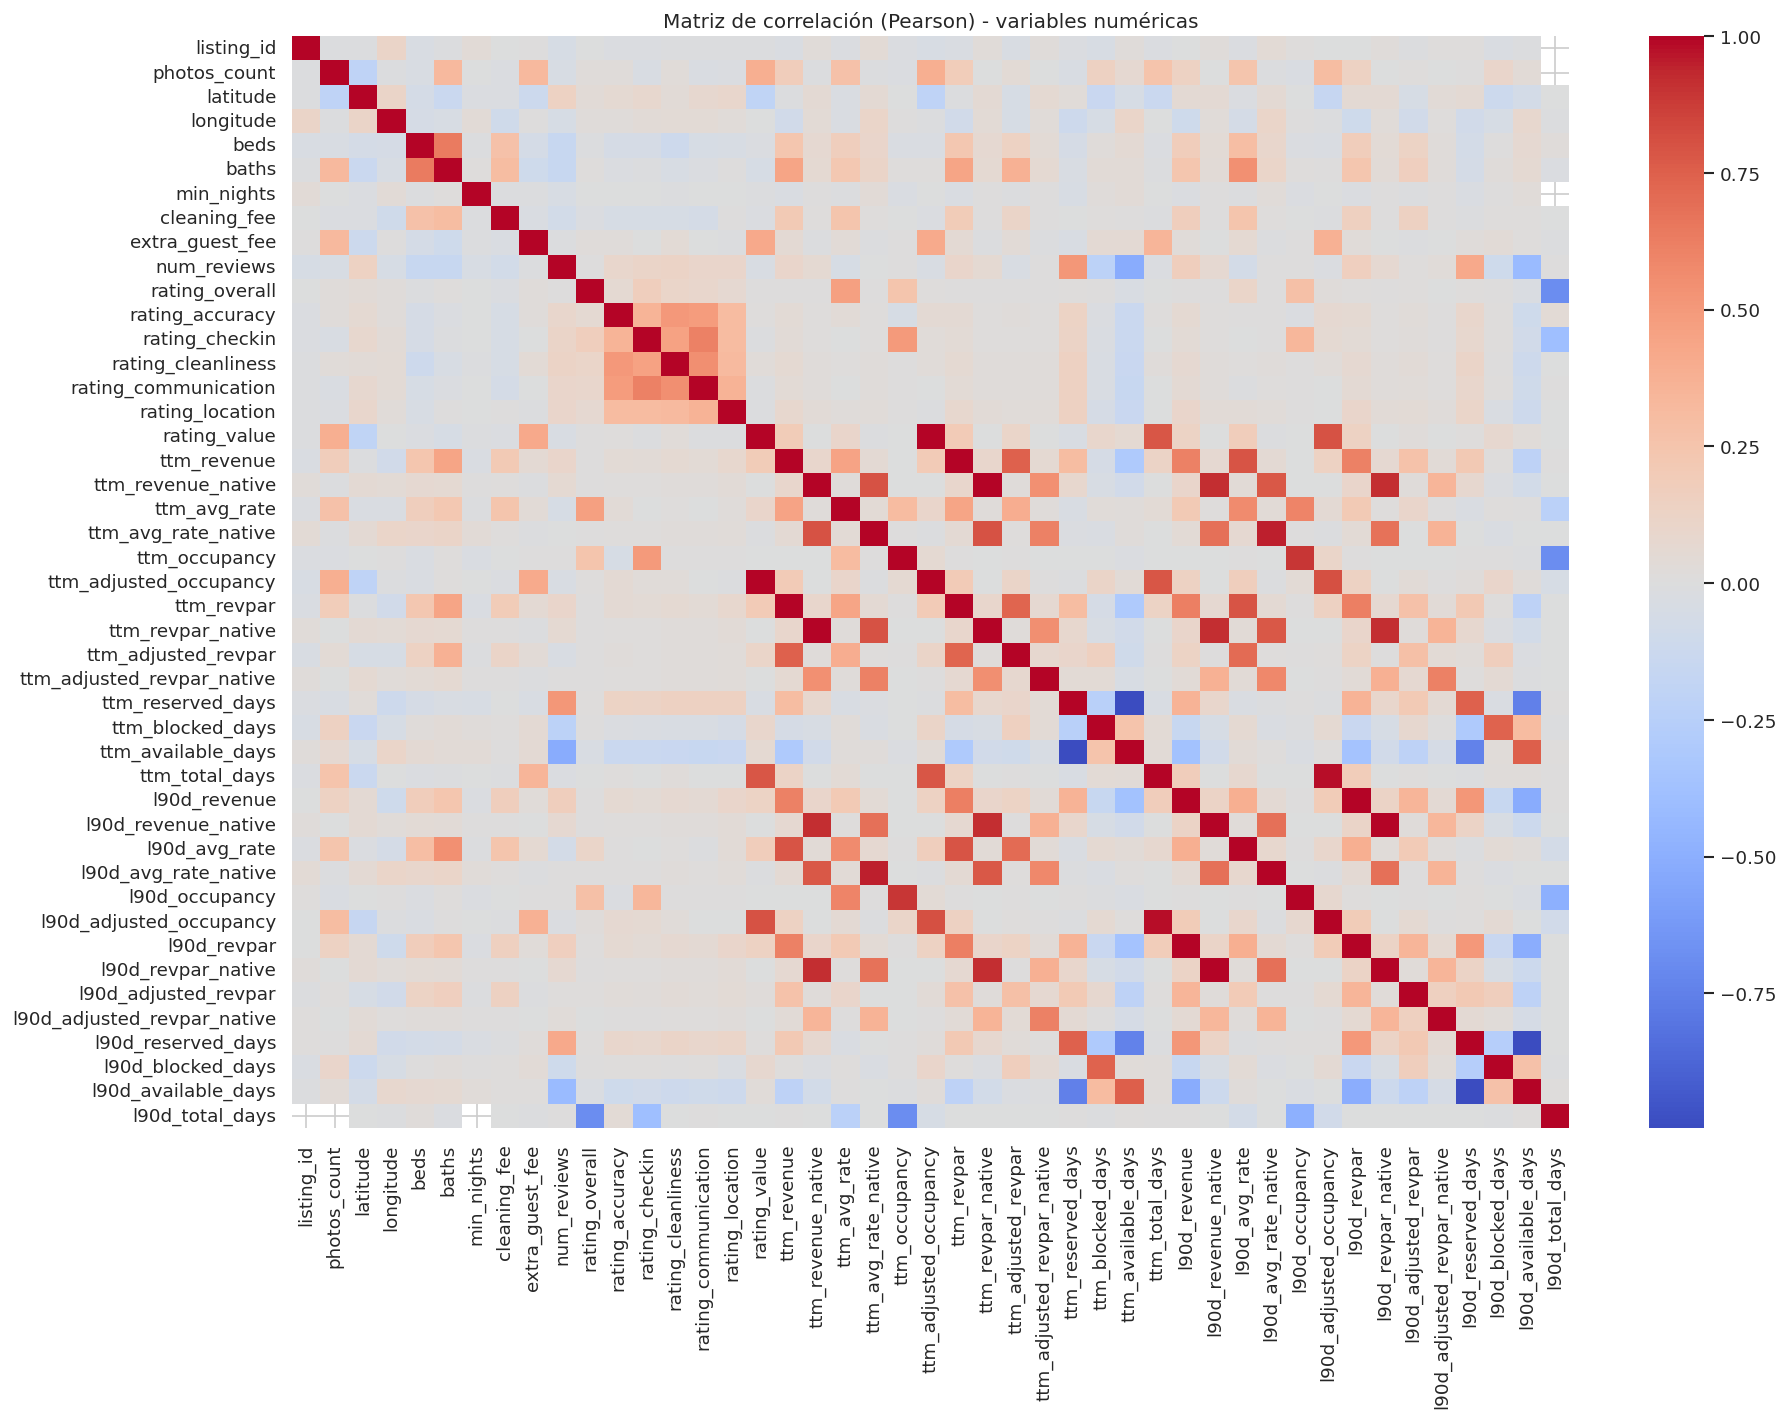

In [ ]:

# 0) confirma tipos (deberías ver muchos object/string)
print(df.dtypes.head(20))

# 1) columnas que deben ser numéricas según tu header
numeric_cols = [
    "listing_id","photos_count","latitude","longitude",
    "guests","bedrooms","beds","baths",
    "min_nights",
    "cleaning_fee","extra_guest_fee",
    "num_reviews",
    "rating_overall","rating_accuracy","rating_checkin","rating_cleanliness",
    "rating_communication","rating_location","rating_value",
    "ttm_revenue","ttm_revenue_native","ttm_avg_rate","ttm_avg_rate_native",
    "ttm_occupancy","ttm_adjusted_occupancy","ttm_revpar","ttm_revpar_native",
    "ttm_adjusted_revpar","ttm_adjusted_revpar_native",
    "ttm_reserved_days","ttm_blocked_days","ttm_available_days","ttm_total_days",
    "l90d_revenue","l90d_revenue_native","l90d_avg_rate","l90d_avg_rate_native",
    "l90d_occupancy","l90d_adjusted_occupancy","l90d_revpar","l90d_revpar_native",
    "l90d_adjusted_revpar","l90d_adjusted_revpar_native",
    "l90d_reserved_days","l90d_blocked_days","l90d_available_days","l90d_total_days",
]

# 2) convierte solo las que existan realmente en tu df
present = [c for c in numeric_cols if c in df.columns]
for c in present:
    df[c] = pd.to_numeric(df[c], errors="coerce")

num = df[present].copy()

# 3) limpia columnas que no sirven para correlación
num = num.dropna(axis=1, how="all")
num = num.loc[:, num.nunique(dropna=True) > 1]  # quita constantes

corr = num.corr(method="pearson")
print("num shape:", num.shape, "corr shape:", corr.shape)

corr.to_csv("correlation_matrix_pearson.csv", index=True)

# 4) heatmap seguro (solo si hay >=2 columnas)
if corr.shape[0] >= 2:
    plt.figure(figsize=(16, 12))
    sns.heatmap(corr, cmap="coolwarm", center=0)
    plt.title("Matriz de correlación (Pearson) - variables numéricas")
    plt.tight_layout()
    plt.savefig("correlation_heatmap_pearson.png", dpi=200)
    plt.show()
else:
    print("No hay suficientes columnas numéricas convertidas para graficar.")

df.shape: (1115174, 17)
listing_id                  int64
date                       object
vacant_days                 int32
reserved_days               int32
occupancy                 float64
revenue                   float64
rate_avg                  float64
booked_rate_avg           float64
booking_lead_time_avg     float64
length_of_stay_avg        float64
min_nights_avg            float64
native_booked_rate_avg    float64
native_rate_avg           float64
native_revenue            float64
country                    object
state                      object
city                       object
dtype: object
num shape: (1115174, 13) corr shape: (13, 13)
                        listing_id  vacant_days  reserved_days  occupancy  \
listing_id                   1.000        0.009         -0.009     -0.009   
vacant_days                  0.009        1.000         -0.997     -0.998   
reserved_days               -0.009       -0.997          1.000      0.999   
occupancy                   -0

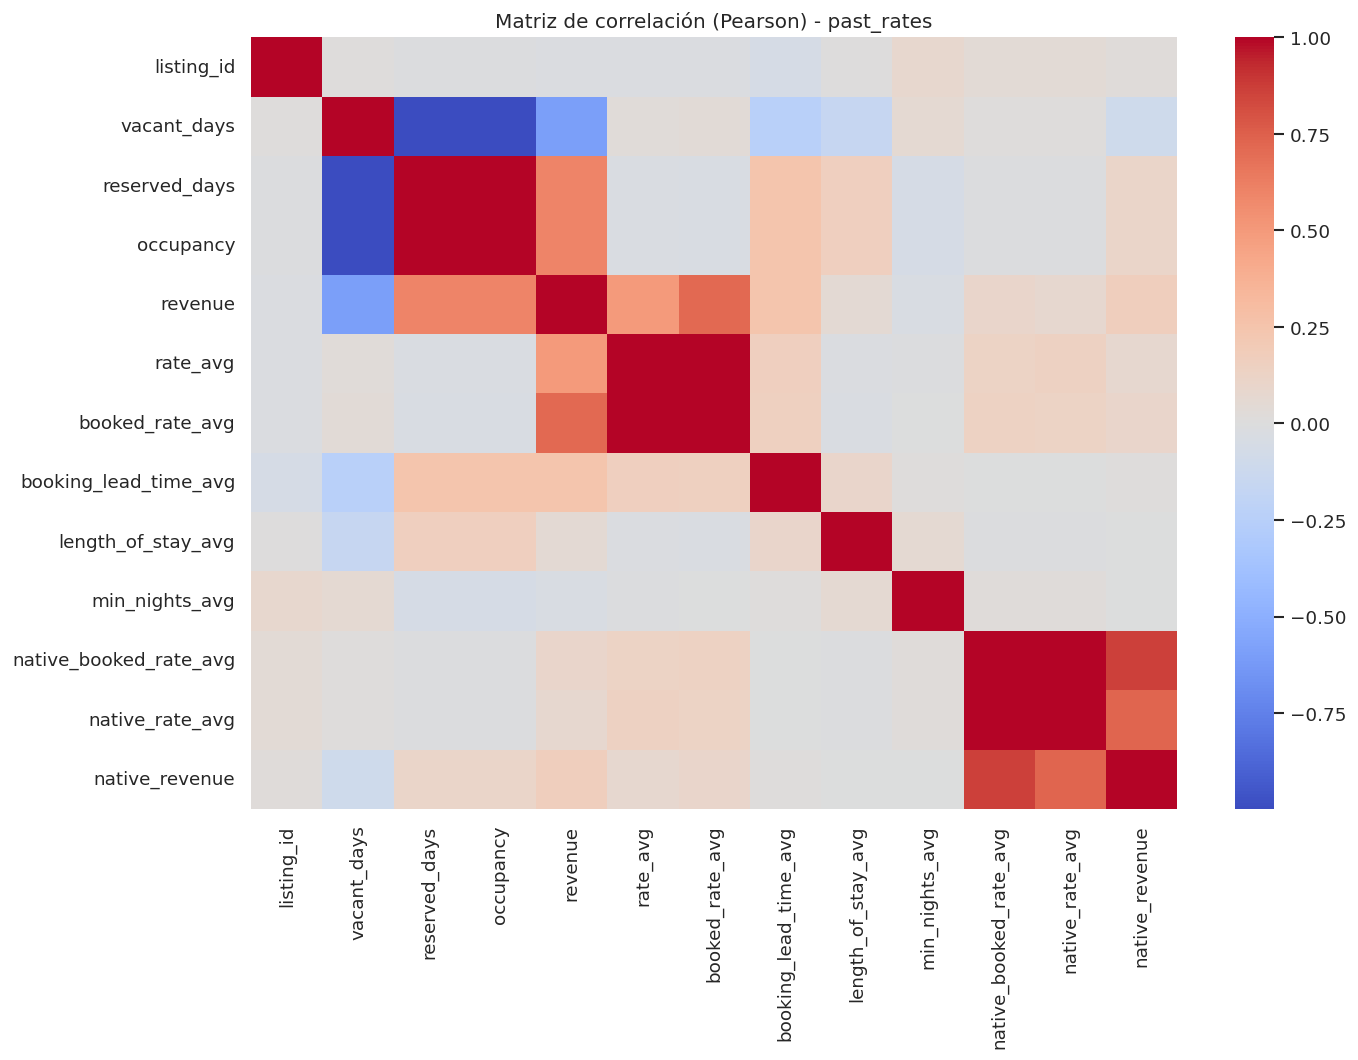

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/Rajevic-0/Proyecto-Mineria-De-Datos/21614a18231f34a2f38d2e238fca764d134ef4a2/past_rates.parquet"
df = pd.read_parquet(url, engine="pyarrow")
print("df.shape:", df.shape)
print(df.dtypes)

# Columnas numéricas esperadas (según tu header)
numeric_cols = [
    "listing_id",
    "vacant_days","reserved_days","occupancy",
    "revenue","rate_avg","booked_rate_avg",
    "booking_lead_time_avg","length_of_stay_avg","min_nights_avg",
    "native_booked_rate_avg","native_rate_avg","native_revenue"
]

present = [c for c in numeric_cols if c in df.columns]

# Convierte a numérico (coerce -> NaN si hay strings raros)
for c in present:
    df[c] = pd.to_numeric(df[c], errors="coerce")

num = df[present].copy()
num = num.dropna(axis=1, how="all")
num = num.loc[:, num.nunique(dropna=True) > 1]

corr = num.corr(method="pearson")
print("num shape:", num.shape, "corr shape:", corr.shape)

corr.to_csv("correlation_matrix_past_rates_pearson.csv", index=True)
print(corr.round(3))

# Heatmap (si la matriz es grande, puede ser pesado)
if corr.shape[0] >= 2:
    plt.figure(figsize=(12, 9))
    sns.heatmap(corr, cmap="coolwarm", center=0)
    plt.title("Matriz de correlación (Pearson) - past_rates")
    plt.tight_layout()
    plt.savefig("correlation_heatmap_past_rates_pearson.png", dpi=200)
    plt.show()